# Depth Comparison: Input vs Output

This notebook compares the input depth EXR against the output depth EXR produced by the pipeline.
It will:
- Load depth EXR files (float) from `scripts/run_files`
- Plot histograms of depth values for both images (shared bin range)
- Show a pixel-wise, signed difference heatmap (output − input)
- Create and save a scaled difference magnitude preview image for quick inspection

Notes:
- Non-finite values (NaN/Inf) are masked.
- If shapes differ, the output depth is resized to match the input (nearest).

In [33]:
# Imports
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings
import os

# Prefer OpenCV for EXR; fallback to imageio
try:
    os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
    import cv2
except Exception as e:
    cv2 = None

try:
    import imageio.v3 as iio
except Exception as e:
    iio = None

# Optional OpenEXR fallback (may not be installed)
try:
    import OpenEXR, Imath
except Exception:
    OpenEXR = None
    Imath = None

%matplotlib inline

In [34]:
# Paths: notebook is in scripts/post_analysis; run_files is a sibling folder
base = Path.cwd()
run_dir = (base.parent / 'run_files').resolve()
input_exr = run_dir / 'batch_inputs' / 'seq4' / 'step0.camera1.Depth.exr'
output_exr = run_dir / 'batch_outputs' / 'seq4' / 'raw' / 'depth.npy'

print('Notebook dir:', base)
print('Run dir:', run_dir)
print('Input depth EXR:', input_exr)
print('Output depth EXR:', output_exr)

if not input_exr.exists():
    raise FileNotFoundError(f'Missing input EXR: {input_exr}')
if not output_exr.exists():
    raise FileNotFoundError(f'Missing output EXR: {output_exr}')

Notebook dir: c:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\post_analysis
Run dir: C:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files
Input depth EXR: C:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\batch_inputs\seq4\step0.camera1.Depth.exr
Output depth EXR: C:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\batch_outputs\seq4\raw\depth.npy


In [35]:
# Robust EXR reader that tries cv2, then imageio, then OpenEXR if available
def _as_single_channel_float(arr):
    if arr is None:
        return None
    arr = np.array(arr)
    # Resize shape
    if arr.shape[-1] == 4:
        arr = arr[..., 2]
    elif arr.ndim == 3:
        arr = arr[..., 2]
    # Clean non-finite
    mask = ~np.isfinite(arr)
    if mask.any():
        arr = arr.copy()
        arr[mask] = np.nan
    return arr

def read_exr_cv2(path):
        os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
        img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        return _as_single_channel_float(img)

def read_npy(path):
    try:
        arr = np.load(path)
        return _as_single_channel_float(arr)
    except Exception as e:
        print(f"Error reading NPY {path}: {e}")
        return None

def read_depth(path):
    path = Path(path)
    if path.suffix.lower() == '.npy':
        return read_npy(path)
    else:
        # Default to EXR reader
        return read_exr_cv2(path)

In [36]:
# Load depths
depth_in = read_depth(input_exr)
depth_out = read_depth(output_exr)

print('Input depth shape:', depth_in.shape, 'dtype:', depth_in.dtype)
print('Output depth shape:', depth_out.shape, 'dtype:', depth_out.dtype)

# If shapes differ, resize output to match input
if depth_in.shape != depth_out.shape:
    warnings.warn(f'Shape mismatch {depth_in.shape} vs {depth_out.shape}; resizing output to input')
    if cv2 is None:
        raise RuntimeError('OpenCV required to resize depth; please install opencv-python')
    h, w = depth_in.shape[:2]
    depth_out = cv2.resize(depth_out, (w, h), interpolation=cv2.INTER_NEAREST)

def stats(name, a):
    finite = np.isfinite(a)
    if not finite.any():
        print(f'{name}: no finite values')
        return
    v = a[finite]
    print(f'{name}: count={v.size}, min={np.nanmin(v):.6g}, max={np.nanmax(v):.6g}, mean={np.nanmean(v):.6g}')

stats('Input', depth_in)
stats('Output', depth_out)

Input depth shape: (400, 650) dtype: float32
Output depth shape: (400, 650) dtype: float32
Input: count=260000, min=0, max=489.178, mean=60.3921
Output: count=260000, min=0, max=999.957, mean=101.951


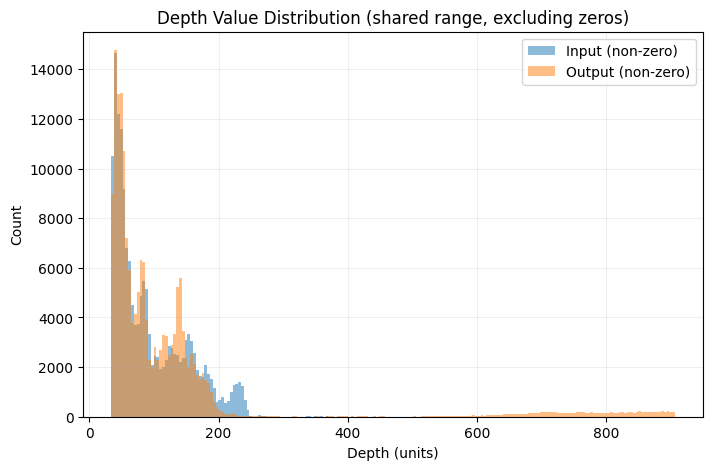

In [31]:
# Histograms with shared range and bins (excluding zeros)
mask_in = np.isfinite(depth_in) & (depth_in != 0)
mask_out = np.isfinite(depth_out) & (depth_out != 0)
vals_in = depth_in[mask_in] if mask_in.any() else np.array([])
vals_out = depth_out[mask_out] if mask_out.any() else np.array([])

if vals_in.size == 0 or vals_out.size == 0:
    raise RuntimeError('One of the depth images has no finite non-zero values')

combined = np.concatenate([vals_in, vals_out])
lo = float(np.nanpercentile(combined, 1))
hi = float(np.nanpercentile(combined, 99))
if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
    lo, hi = float(np.nanmin(combined)), float(np.nanmax(combined))
bins = 200

plt.figure(figsize=(8, 5))
plt.hist(vals_in, bins=bins, range=(lo, hi), alpha=0.5, color='tab:blue', label='Input (non-zero)', histtype='stepfilled')
plt.hist(vals_out, bins=bins, range=(lo, hi), alpha=0.5, color='tab:orange', label='Output (non-zero)', histtype='stepfilled')
plt.title('Depth Value Distribution (shared range, excluding zeros)')
plt.xlabel('Depth (units)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

--- Statistics (Val >= 50.0) ---
  Mean Absolute Error (MAE): 11.5651 (Sensitive to outliers)
  Root Mean Sq Error (RMSE): 24.6950
  Median Abs Error (MedAE):  5.3284 (Robust to outliers)
---------------------------------------------


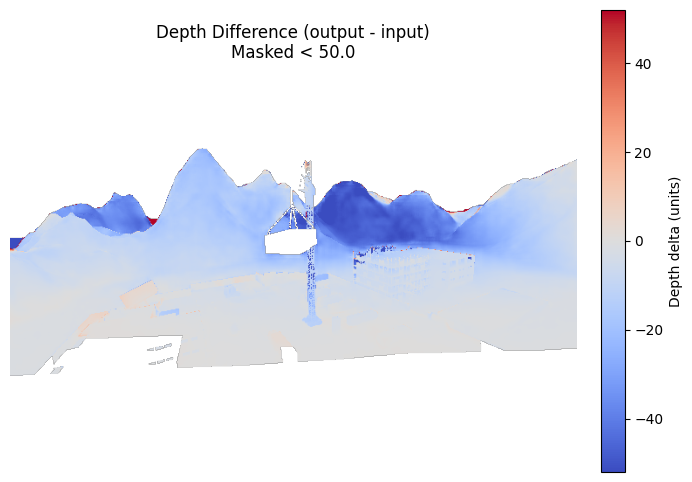

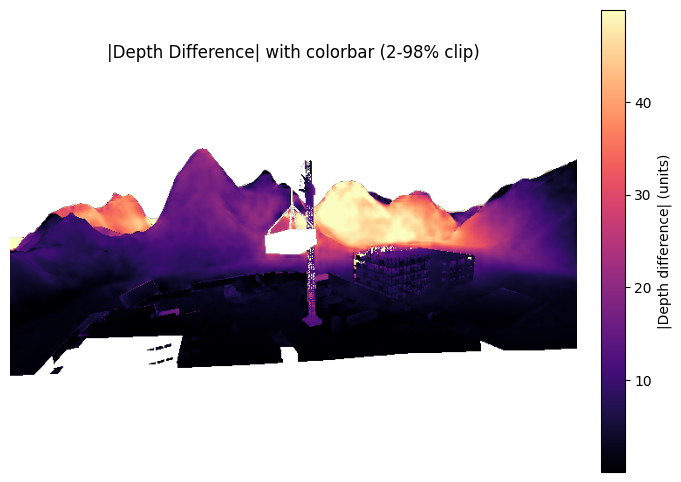

Saved: C:\Users\1213123\Documents\Scripts\FoundationStereo\scripts\run_files\output_3d_blocks\depth_diff_scaled.png


In [32]:
# Pixel-wise signed difference (output - input) visualization and scaled magnitude image

# --- OUTLIER HANDLING ---
# Strategy 1: Thresholding.
# If data is Disparity (inverse depth): Foreground > Background. Use (val >= Threshold).
# If data is Depth (meters): Foreground < Background. Use (val <= Threshold).
# Based on user feedback, we use >= to isolate foreground, which implies the data is likely Disparity.
MIN_VALID_VAL = 50.0  # Threshold. Values below this are considered background/ignored.

valid = np.isfinite(depth_in) & np.isfinite(depth_out)
if MIN_VALID_VAL is not None:
    valid &= (depth_in >= MIN_VALID_VAL)

if not valid.any():
    raise RuntimeError('No overlapping finite pixels between input and output depth')

diff = np.full_like(depth_in, np.nan, dtype=np.float32)
diff[valid] = depth_out[valid] - depth_in[valid]

# Strategy 2: Robust Statistics (Median vs Mean)
mae = np.mean(np.abs(diff[valid]))
rmse = np.sqrt(np.mean(diff[valid]**2))
med_ae = np.median(np.abs(diff[valid]))

print(f"--- Statistics (Val >= {MIN_VALID_VAL}) ---")
print(f"  Mean Absolute Error (MAE): {mae:.4f} (Sensitive to outliers)")
print(f"  Root Mean Sq Error (RMSE): {rmse:.4f}")
print(f"  Median Abs Error (MedAE):  {med_ae:.4f} (Robust to outliers)")
print(f"---------------------------------------------")

# Robust symmetric color scaling around zero
vals = diff[valid]
neg = float(np.nanpercentile(vals, 1))
pos = float(np.nanpercentile(vals, 99))
m = max(abs(neg), abs(pos)) if np.isfinite(neg) and np.isfinite(pos) else float(np.nanmax(np.abs(vals)))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-m, vmax=m)

plt.figure(figsize=(8, 6))
im = plt.imshow(diff, cmap='coolwarm', norm=norm)
plt.title(f'Depth Difference (output - input)\nMasked < {MIN_VALID_VAL}')
plt.axis('off')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Depth delta (units)')
plt.show()

# Scaled magnitude image for quick preview and a colorbar in depth units
mag = np.abs(diff)
mag_vals = mag[valid]
p2, p98 = np.nanpercentile(mag_vals, [2, 98])
if not np.isfinite(p2) or not np.isfinite(p98) or p98 <= p2:
    p2, p98 = float(np.nanmin(mag_vals)), float(np.nanmax(mag_vals))

# Show with a perceptual colormap and a colorbar labeled in depth units
plt.figure(figsize=(8, 6))
im2 = plt.imshow(mag, cmap='magma', vmin=p2, vmax=p98)
plt.title('|Depth Difference| with colorbar (2-98% clip)')
plt.axis('off')
plt.colorbar(im2, fraction=0.046, pad=0.04, label='|Depth difference| (units)')
plt.show()

# Also produce an 8-bit scaled image (0..255) for saving to disk
scaled = np.zeros_like(mag, dtype=np.float32)
np.divide(np.clip(mag - p2, 0, None), max(p98 - p2, 1e-6), out=scaled, where=np.isfinite(mag))
scaled_u8 = (np.clip(scaled, 0, 1) * 255).astype(np.uint8)

# Save scaled difference image next to output files
save_path = run_dir / 'output_3d_blocks' / 'depth_diff_scaled.png'
try:
    if cv2 is not None:
        cv2.imwrite(str(save_path), scaled_u8)
    elif iio is not None:
        iio.imwrite(str(save_path), scaled_u8)
    else:
        raise RuntimeError('No available writer (cv2/imageio) to save the image')
    print('Saved:', save_path)
except Exception as e:
    warnings.warn(f'Could not save scaled diff image: {e}')